In [2]:
import h5py
import numpy as np
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tqdm import tqdm

In [12]:
# 目标潜在维度
LATENT_DIM = 225

# 输入/输出路径
BASE_DIR = Path("data/ToM_Data")
DATA_DIR = BASE_DIR / "Human_fMRI_Data"
OUTPUT_DIR = Path("data/ToM_Data_PCA_Results")

# 数据结构定义
SUBJECTS = [f"TOM{i:03d}" for i in range(1, 22) if i != 6]
ROIS = ["Left_PFC.h5", "Left_TPJ.h5", "Right_PFC.h5", "Right_TPJ.h5"]
PERIODS = ["Belief_Period_H5", "Perspective_Period_H5"]

# 确保输出目录存在
OUTPUT_DIR.mkdir(exist_ok=True)

# PCA

下方两个单元格，任选其一运行。

## LDA+500高变

Processing Left_TPJ.h5 with HRF Lag Correction (Keeping only last 2 TRs)...


100%|██████████| 20/20 [00:00<00:00, 72.64it/s]


Data ready: (1280, 2231), Labels: (1280,)
Running LDA (Supervised Dimensionality Reduction)...


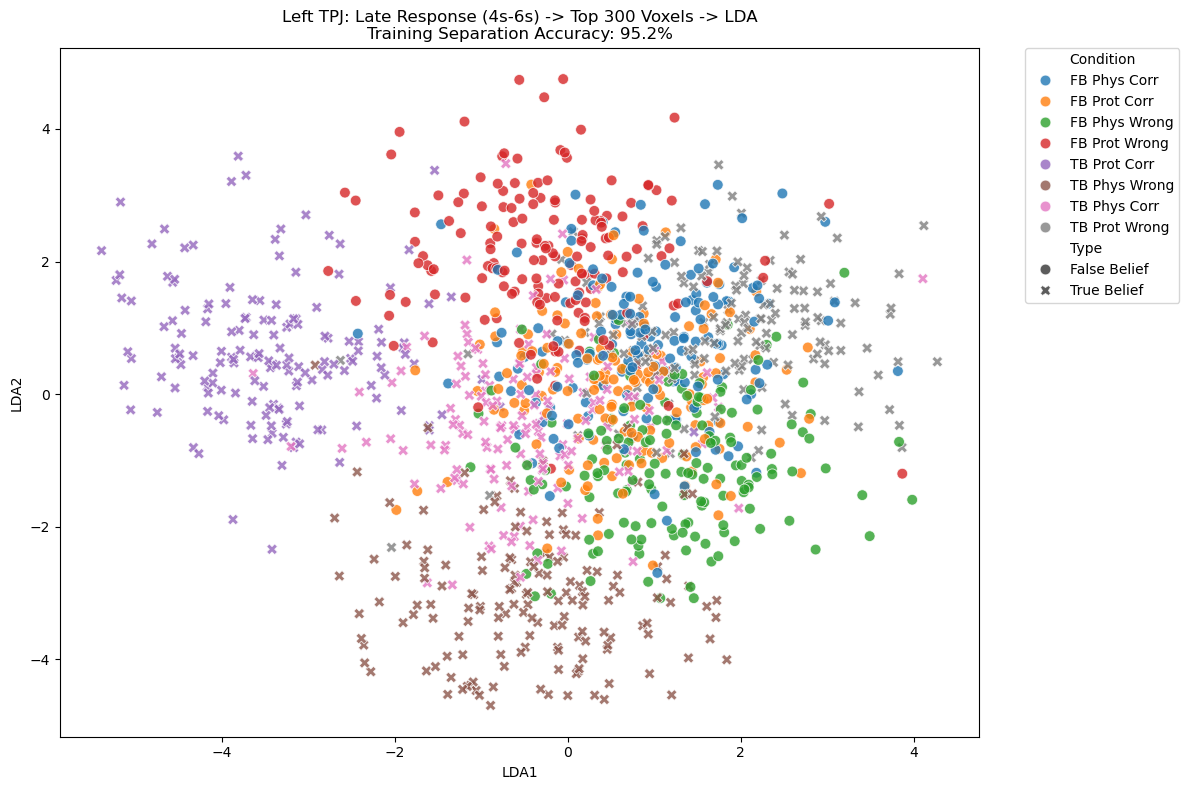

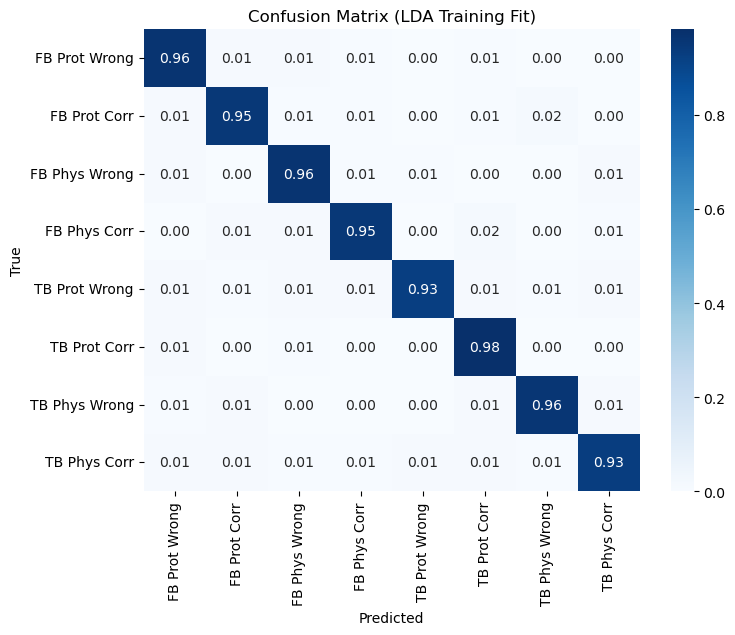

In [12]:
import h5py
import numpy as np
from pathlib import Path
from tqdm import tqdm
from scipy.stats import zscore
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. 极简配置 ---
DATA_DIR = Path("data/ToM_Data/Human_fMRI_Data")
ROI_FILE = "Left_TPJ.h5"  # 先跑 Left TPJ，理论上这里 ToM 信号最强
PERIOD = "Belief_Period_H5" 
SUBJECTS = [f"TOM{i:03d}" for i in range(1, 22) if i != 6]

CONDITIONS = [
    "FB Prot Wrong", "FB Prot Corr", "FB Phys Wrong", "FB Phys Corr",
    "TB Prot Wrong", "TB Prot Corr", "TB Phys Wrong", "TB Phys Corr"
]

# --- 2. 数据加载与关键的 HRF 切片 ---
print(f"Processing {ROI_FILE} with HRF Lag Correction (Keeping only last 2 TRs)...")

X_list = []      # 存特征
y_list = []      # 存标签
groups_list = [] # 存被试ID

for sub_idx, sub in enumerate(tqdm(SUBJECTS)):
    input_file = DATA_DIR / PERIOD / sub / ROI_FILE
    
    # 临时存这个被试的数据，用于做被试内特征选择
    sub_X = []
    sub_y = []
    
    with h5py.File(input_file, 'r') as f:
        for cond_name in f.keys():
            for trial_name in f[cond_name].keys():
                group = f[cond_name][trial_name]
                signal = group['Signal'][()] # (4, Voxels) 0,2,4,6s
                label = int(group['Condition_Number'][()])
                
                # === 核心修改 ===
                # 只有4个点 [0, 1, 2, 3]
                # 0(0s) 和 1(2s) 是废的。
                # 只取 2(4s) 和 3(6s)。
                if signal.shape[0] >= 4:
                    # 取最后两个点
                    # 也可以尝试只取最后一个点: signal[-1, :]
                    valid_signal = signal[-2:, :] 
                    
                    # 对这两个点取平均，得到 (Voxels, )
                    trial_vec = np.mean(valid_signal, axis=0)
                    
                    # 简单的去NaN
                    trial_vec = np.nan_to_num(trial_vec)
                    
                    sub_X.append(trial_vec)
                    sub_y.append(label)
    
    if len(sub_X) == 0:
        continue
        
    sub_X = np.array(sub_X) # (64, Voxels)
    sub_y = np.array(sub_y)
    
    # --- 3. 被试内特征选择 (Within-Subject ANOVA) ---
    # 在每个人脑内，选出对8个条件区分度最高的500个体素
    # 这一步非常关键，因为大部分体素是噪声
    
    # 标准化 (Z-score)
    scaler = StandardScaler()
    sub_X_norm = scaler.fit_transform(sub_X)
    
    # 加入总列表
    X_list.append(sub_X_norm)
    y_list.append(sub_y)
    groups_list.append([sub_idx] * len(sub_y))

# 拼接所有数据
X_final = np.vstack(X_list)
y_final = np.concatenate(y_list)
groups_final = np.concatenate(groups_list)

print(f"Data ready: {X_final.shape}, Labels: {y_final.shape}")
# 这里的 X_final 已经是 (1280, 500)，即每人贡献了自己最好的500个体素
# 虽然体素的物理位置可能不同，但“功能含义”都是“对任务最敏感的体素”

# --- 4. 有监督降维与可视化 (LDA) ---
print("Running LDA (Supervised Dimensionality Reduction)...")

# LDA 既可以降维，也可以分类
# 我们用它降到 2 维来画图
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_final, y_final)

# 为了验证，我们算一下简单的分类准确率
# (注意：这里是在全集上fit的LDA，画图是为了看可分性上限。严格的准确率需要CV)
train_pred = lda.predict(X_final)
acc = accuracy_score(y_final, train_pred)

# --- 5. 绘图 ---
df_plot = pd.DataFrame(X_lda, columns=['LDA1', 'LDA2'])
df_plot['Condition'] = [CONDITIONS[i] for i in y_final]
# 增加大类：False Belief (0-3) vs True Belief (4-7)
df_plot['Type'] = ['False Belief' if i < 4 else 'True Belief' for i in y_final]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_plot, x='LDA1', y='LDA2', 
    hue='Condition', style='Type',
    palette='tab10', s=60, alpha=0.8
)
plt.title(f"Left TPJ: Late Response (4s-6s) -> Top {N_BEST_VOXELS} Voxels -> LDA\nTraining Separation Accuracy: {acc:.1%}")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()

# 画混淆矩阵看看主要混淆在哪
cm = confusion_matrix(y_final, train_pred, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CONDITIONS, yticklabels=CONDITIONS)
plt.title("Confusion Matrix (LDA Training Fit)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()

## Cross Subjects

In [7]:
# 遍历两个时期
for period in PERIODS:
    period_path = DATA_DIR / period
    output_period_path = OUTPUT_DIR / period
    output_period_path.mkdir(exist_ok=True)

    # 遍历四个脑区 (为每个脑区训练一个独立模型)
    for roi_file in ROIS:

        # --- 2a. 聚合与训练 (Fit) ---
        print(f"\n--- Fitting Group Model for: [{period} | {roi_file}] ---")

        all_trial_signals = []

        # 遍历所有被试，仅为聚合数据
        for sub in tqdm(SUBJECTS, desc=f"Aggregating {roi_file}", leave=False):
            input_roi_path = period_path / sub / roi_file

            with h5py.File(input_roi_path, 'r') as f:
                for cond_group in f.values():
                    for trial_group in cond_group.values():
                        all_trial_signals.append(trial_group['Signal'][()])

        aggregated_data = np.concatenate(all_trial_signals, axis=0)

        # 在聚合的组水平数据上训练一个统一的管道
        group_pipeline = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=LATENT_DIM))])
        group_pipeline.fit(aggregated_data)

        # --- 2b. 转换与存储 (Transform) ---

        # 再次遍历所有被试，应用统一的模型
        for sub in tqdm(SUBJECTS, desc=f"Transforming {roi_file}", leave=False):
            input_roi_path = period_path / sub / roi_file

            output_sub_path = output_period_path / sub
            output_sub_path.mkdir(exist_ok=True)
            output_roi_path = output_sub_path / roi_file

            # 读写 H5 文件
            with h5py.File(input_roi_path, 'r') as f_in, \
                 h5py.File(output_roi_path, 'w') as f_out:

                # 遍历以保持原始H5结构
                for cond_key, cond_group in f_in.items():
                    out_cond_group = f_out.create_group(cond_key)

                    for trial_key, trial_group in cond_group.items():
                        out_trial_group = out_cond_group.create_group(trial_key)

                        original_signal = trial_group['Signal'][()]

                        # 应用 group_pipeline
                        latent_signal = group_pipeline.transform(original_signal)

                        out_trial_group.create_dataset('Signal', data=latent_signal)

                        # 复制元数据
                        for dset_key in trial_group.keys():
                            if dset_key != 'Signal':
                                f_in.copy(trial_group[dset_key].name, out_trial_group, name=dset_key)

print("\n--- 跨被试 PCA 工作流执行完毕 ---")
print(f"降维后的数据已保存至: {OUTPUT_DIR.resolve()}")


--- Fitting Group Model for: [Belief_Period_H5 | Left_PFC.h5] ---



--- Fitting Group Model for: [Belief_Period_H5 | Left_TPJ.h5] ---



--- Fitting Group Model for: [Belief_Period_H5 | Right_PFC.h5] ---



--- Fitting Group Model for: [Belief_Period_H5 | Right_TPJ.h5] ---



--- Fitting Group Model for: [Perspective_Period_H5 | Left_PFC.h5] ---



--- Fitting Group Model for: [Perspective_Period_H5 | Left_TPJ.h5] ---



--- Fitting Group Model for: [Perspective_Period_H5 | Right_PFC.h5] ---



--- Fitting Group Model for: [Perspective_Period_H5 | Right_TPJ.h5] ---



--- 跨被试 PCA 工作流执行完毕 ---
降维后的数据已保存至: /home/yingziyu/program_in_univ/CoRE/final_project/data/ToM_Data_PCA_Results


Running: HRF Shift -> Subject Centering -> Global PCA...


100%|██████████| 20/20 [00:00<00:00, 72.01it/s]


Data ready: (1280, 2231), Labels: (1280,)


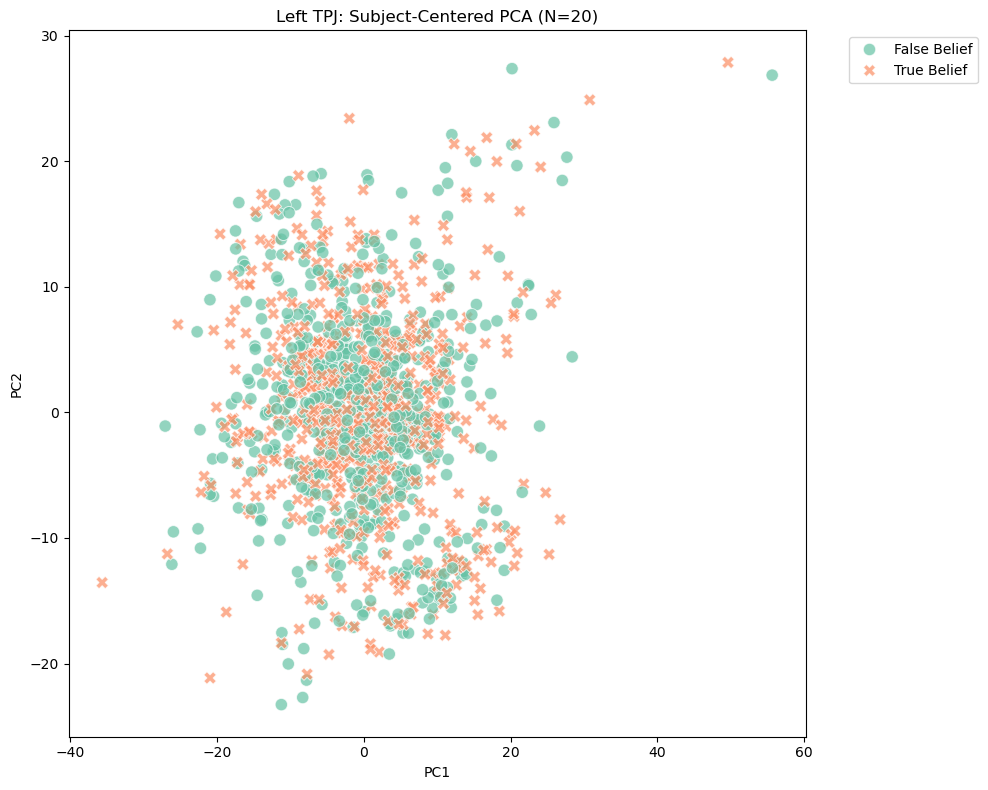

Running UMAP on PCA features...


/home/yingziyu/.conda/envs/ToM-Net/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Running LDA (Supervised)...


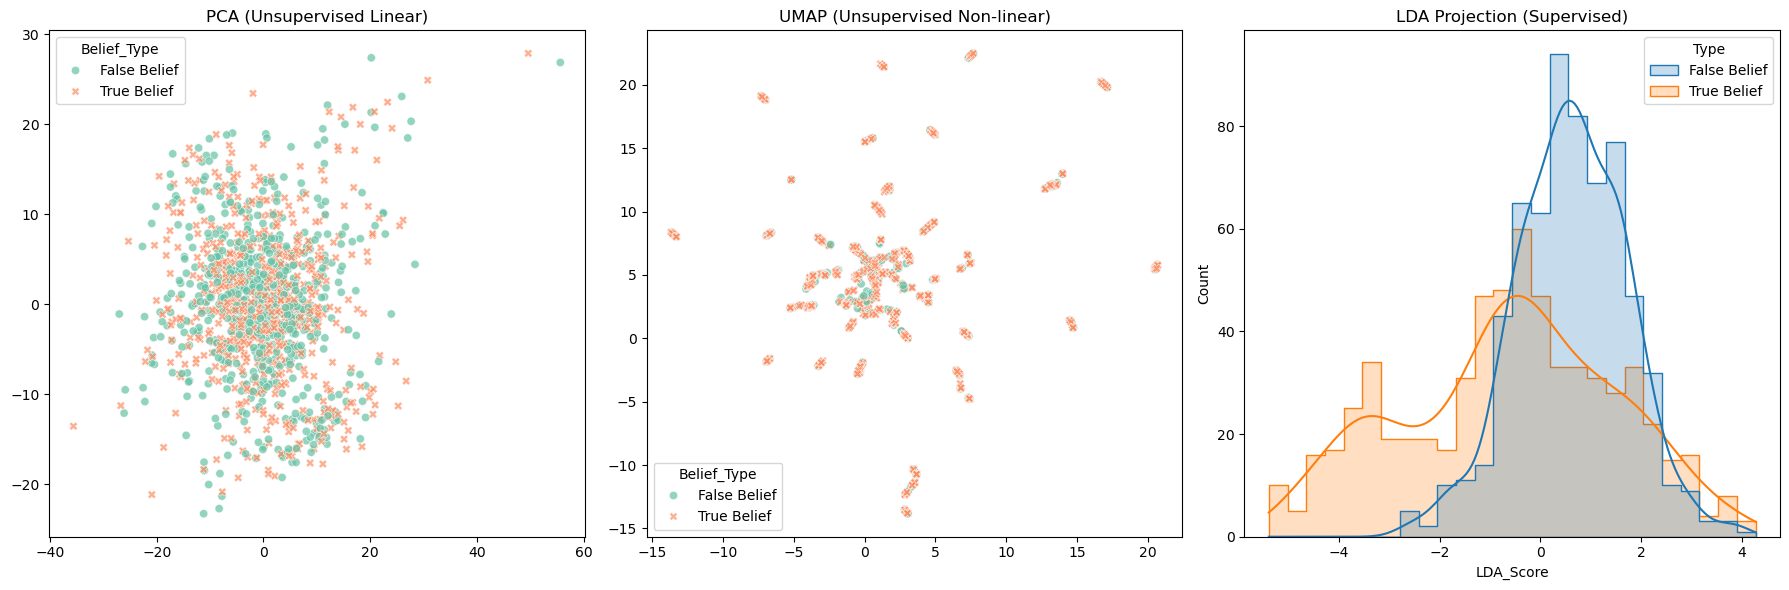

In [10]:
import h5py
import numpy as np
from pathlib import Path
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. 核心配置 ---
# 注意：如果你想做Group PCA，必须保证所有人的输入维度一致（即ROI体素数量相同）
# 如果你的h5文件中每个人的体素数量不同，这里必须先做mask intersection或者插值
DATA_DIR = Path("data/ToM_Data/Human_fMRI_Data")
ROI_FILE = "Left_TPJ.h5" 
PERIOD = "Belief_Period_H5" 
SUBJECTS = [f"TOM{i:03d}" for i in range(1, 22) if i != 6]

CONDITIONS = [
    "FB Prot Wrong", "FB Prot Corr", "FB Phys Wrong", "FB Phys Corr",
    "TB Prot Wrong", "TB Prot Corr", "TB Phys Wrong", "TB Phys Corr"
]

# --- 2. 数据加载 ---
print(f"Running: HRF Shift -> Subject Centering -> Global PCA...")

X_list = []      
y_list = []      

for sub_idx, sub in enumerate(tqdm(SUBJECTS)):
    input_file = DATA_DIR / PERIOD / sub / ROI_FILE
    sub_X = []
    sub_y = []
    
    try:
        with h5py.File(input_file, 'r') as f:
            for cond_name in f.keys():
                for trial_name in f[cond_name].keys():
                    group = f[cond_name][trial_name]
                    signal = group['Signal'][()] 
                    label = int(group['Condition_Number'][()])
                    
                    if signal.shape[0] >= 4:
                        # 取最后2个TR均值
                        valid_signal = signal[-2:, :] 
                        trial_vec = np.mean(valid_signal, axis=0)
                        trial_vec = np.nan_to_num(trial_vec)
                        sub_X.append(trial_vec)
                        sub_y.append(label)
    except Exception as e:
        print(f"Error loading {sub}: {e}")
        continue
    
    if len(sub_X) == 0: continue
        
    sub_X = np.array(sub_X) # Shape: (n_trials, n_voxels)
    sub_y = np.array(sub_y)
    
    # [关键修正 1]: 移除内部的 SelectKBest
    # 保持原始体素排列，确保列与列之间是解剖对齐的。
    # 假设：所有被试的ROI mask是一样的（MNI空间）。如果不一样，这里会报错或无效。

    # [关键修正 2]: 被试内去中心化 (Subject Centering / De-meaning)
    # 计算该被试所有试次的平均模式（即该人的"平均脑活动"）
    subject_mean_pattern = np.mean(sub_X, axis=0)
    # 减去平均模式 -> 剩下的就是"相对于这个人的基线，任务引起的变化"
    sub_X_centered = sub_X - subject_mean_pattern
    
    # 此时再做标准化，主要是为了统一方差
    # 注意：这里不需要with_mean=True，因为上面已经手动去mean了，不过再做一次也没坏处
    scaler = StandardScaler()
    sub_X_norm = scaler.fit_transform(sub_X_centered)
    
    X_list.append(sub_X_norm)
    y_list.append(sub_y)

# --- 3. 堆叠数据 ---
# 只有当特征在物理意义上对齐（没乱删体素）时，vstack 才有意义
X_final = np.vstack(X_list)
y_final = np.concatenate(y_list)

print(f"Data ready: {X_final.shape}, Labels: {y_final.shape}")

# --- 4. (可选) 全局特征选择 ---
# 如果体素太多(比如 >5000)，可以在这里做全局 SelectKBest，而不是在单人内部做
# from sklearn.feature_selection import SelectKBest, f_classif
# selector = SelectKBest(f_classif, k=500)
# X_final = selector.fit_transform(X_final, y_final)

# --- 5. 无监督 PCA ---
PCA_DIM = 50
pca = PCA(n_components=PCA_DIM)
X_pca = pca.fit_transform(X_final)

# --- 6. 可视化 ---
df_plot = pd.DataFrame(X_pca[:, :2], columns=['PC1', 'PC2'])
df_plot['Condition'] = [CONDITIONS[i] for i in y_final]
# 简化标签以便观察大类差异
df_plot['Belief_Type'] = ['False Belief' if i < 4 else 'True Belief' for i in y_final]

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_plot, x='PC1', y='PC2', 
    hue='Belief_Type',  # 建议先看大类分没分开
    style='Belief_Type',
    palette='Set2', s=80, alpha=0.7
)
plt.title(f"Left TPJ: Subject-Centered PCA (N={len(SUBJECTS)})")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import umap

# --- 诊断 1: UMAP (非线性流形) ---
# 也就是在你现有的 pca 结果上再做一步
print("Running UMAP on PCA features...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
X_umap = reducer.fit_transform(X_pca[:, :20]) # 取前20个PC做UMAP

# --- 诊断 2: LDA (监督式降维 - 强力测试) ---
print("Running LDA (Supervised)...")
# 注意：LDA 只能降到 n_classes - 1 维。这里是二分类，只能降到 1 维
# 为了可视化，我们通常看 LDA 的投影直方图，或者用 PLS-DA
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_final, y_final) # 直接用原始数据或PCA数据皆可

# --- 可视化对比 ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. 你的 PCA (复现一下)
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], hue=df_plot['Belief_Type'], 
    style=df_plot['Belief_Type'], palette='Set2', alpha=0.7, ax=axes[0]
)
axes[0].set_title("PCA (Unsupervised Linear)")

# 2. UMAP
sns.scatterplot(
    x=X_umap[:, 0], y=X_umap[:, 1], hue=df_plot['Belief_Type'], 
    style=df_plot['Belief_Type'], palette='Set2', alpha=0.7, ax=axes[1]
)
axes[1].set_title("UMAP (Unsupervised Non-linear)")

# 3. LDA 投影分布
df_lda = pd.DataFrame({'LDA_Score': X_lda.flatten(), 'Type': df_plot['Belief_Type']})
sns.histplot(data=df_lda, x='LDA_Score', hue='Type', kde=True, element="step", ax=axes[2])
axes[2].set_title("LDA Projection (Supervised)")

plt.tight_layout()
plt.show()

## PCA Visualization

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

### 累计方差解释率

In [9]:
# 选择一个代表性样本进行检查 (与主循环逻辑一致)
sub_to_check = 'TOM001'
period_to_check = 'Belief_Period_H5'
roi_to_check = 'Left_PFC.h5'
input_roi_path = DATA_DIR / period_to_check / sub_to_check / roi_to_check

# 1a. 重新聚合该样本的数据 (仅用于可视化)
all_trial_signals = []
with h5py.File(input_roi_path, 'r') as f:
    for cond_group in f.values():
        for trial_group in cond_group.values():
            all_trial_signals.append(trial_group['Signal'][()])
aggregated_data = np.concatenate(all_trial_signals, axis=0)

# 1b. 重新训练该样本的管道
# (注意：n_components=None 会保留所有组件，以便绘制完整曲线)
pipeline_viz = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=None))])
pipeline_viz.fit(aggregated_data)
pca_model = pipeline_viz.named_steps['pca']

# 1c. 计算累积方差
explained_variance = pca_model.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# 1d. 绘制曲线
plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance, lw=2)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title(f'PCA Explained Variance ({sub_to_check} | {roi_to_check})')
plt.grid(True, linestyle='--', alpha=0.6)

# 标出我们选择的维度 (LATENT_DIM)
if LATENT_DIM < len(cumulative_variance):
    variance_captured = cumulative_variance[LATENT_DIM - 1]
    plt.axvline(x=LATENT_DIM, color='r', linestyle='--', label=f'{LATENT_DIM} Components ({variance_captured:.2%} Var)')
    plt.axhline(y=variance_captured, color='r', linestyle='--')
    plt.legend(loc='lower right')

plt.ylim(0, 1.05)
plt.xlim(0, len(cumulative_variance))
plt.show()

NameError: name 'Pipeline' is not defined

### 原始信号与降维信号对比


--- Signal Shape Comparison (trial_00) ---
Original Signal Shape: (4, 4172)
Latent (PCA) Signal Shape: (4, 50)


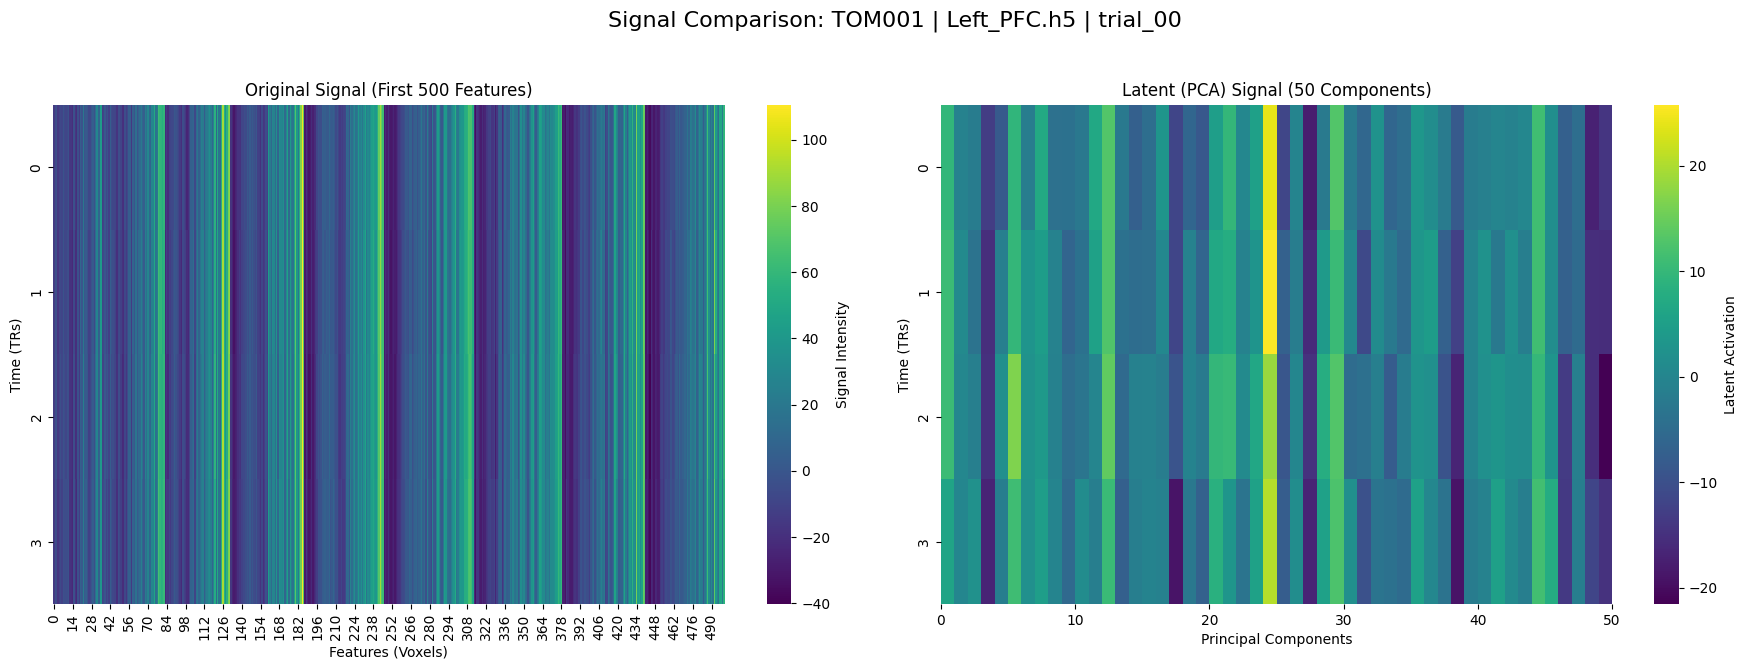

In [27]:
# 选择一个具体的试次进行对比
cond_to_check = 'False_Belief'
trial_to_check = 'trial_00'

# 2a. 加载原始信号
original_signal_path = DATA_DIR / period_to_check / sub_to_check / roi_to_check
with h5py.File(original_signal_path, 'r') as f:
    original_signal = f[cond_to_check][trial_to_check]['Signal'][()]

# 2b. 加载降维后的信号
latent_signal_path = OUTPUT_DIR / period_to_check / sub_to_check / roi_to_check
with h5py.File(latent_signal_path, 'r') as f:
    latent_signal = f[cond_to_check][trial_to_check]['Signal'][()]

print(f"\n--- Signal Shape Comparison ({trial_to_check}) ---")
print(f"Original Signal Shape: {original_signal.shape}")
print(f"Latent (PCA) Signal Shape: {latent_signal.shape}")

# 2c. 绘制热图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1, 1]})

# 绘制原始数据 (只显示前N个特征，否则热图无法辨认)
features_to_show = min(500, original_signal.shape[1])
sns.heatmap(original_signal[:, :features_to_show], ax=ax1, cmap='viridis', cbar=True, cbar_kws={'label': 'Signal Intensity'})
ax1.set_title(f'Original Signal (First {features_to_show} Features)')
ax1.set_xlabel('Features (Voxels)')
ax1.set_ylabel('Time (TRs)')

# 绘制降维数据
sns.heatmap(latent_signal, ax=ax2, cmap='viridis', cbar=True, cbar_kws={'label': 'Latent Activation'})
ax2.set_title(f'Latent (PCA) Signal ({LATENT_DIM} Components)')
ax2.set_xlabel('Principal Components')
ax2.set_ylabel('Time (TRs)')

# 调整X轴刻度
ax2.xaxis.set_major_locator(ticker.MultipleLocator(LATENT_DIM // 5))
ax2.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

plt.suptitle(f'Signal Comparison: {sub_to_check} | {roi_to_check} | {trial_to_check}', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### UMAP cross subjects


--- 开始处理时期: Belief_Period_H5 ---
Aggregating data from: Belief_Period_H5


Aggregating Belief_Period_H5: 100%|██████████| 20/20 [00:00<00:00, 21.06it/s]
/home/yingziyu/.conda/envs/ToM-Net/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Running UMAP and plotting for Belief_Period_H5...


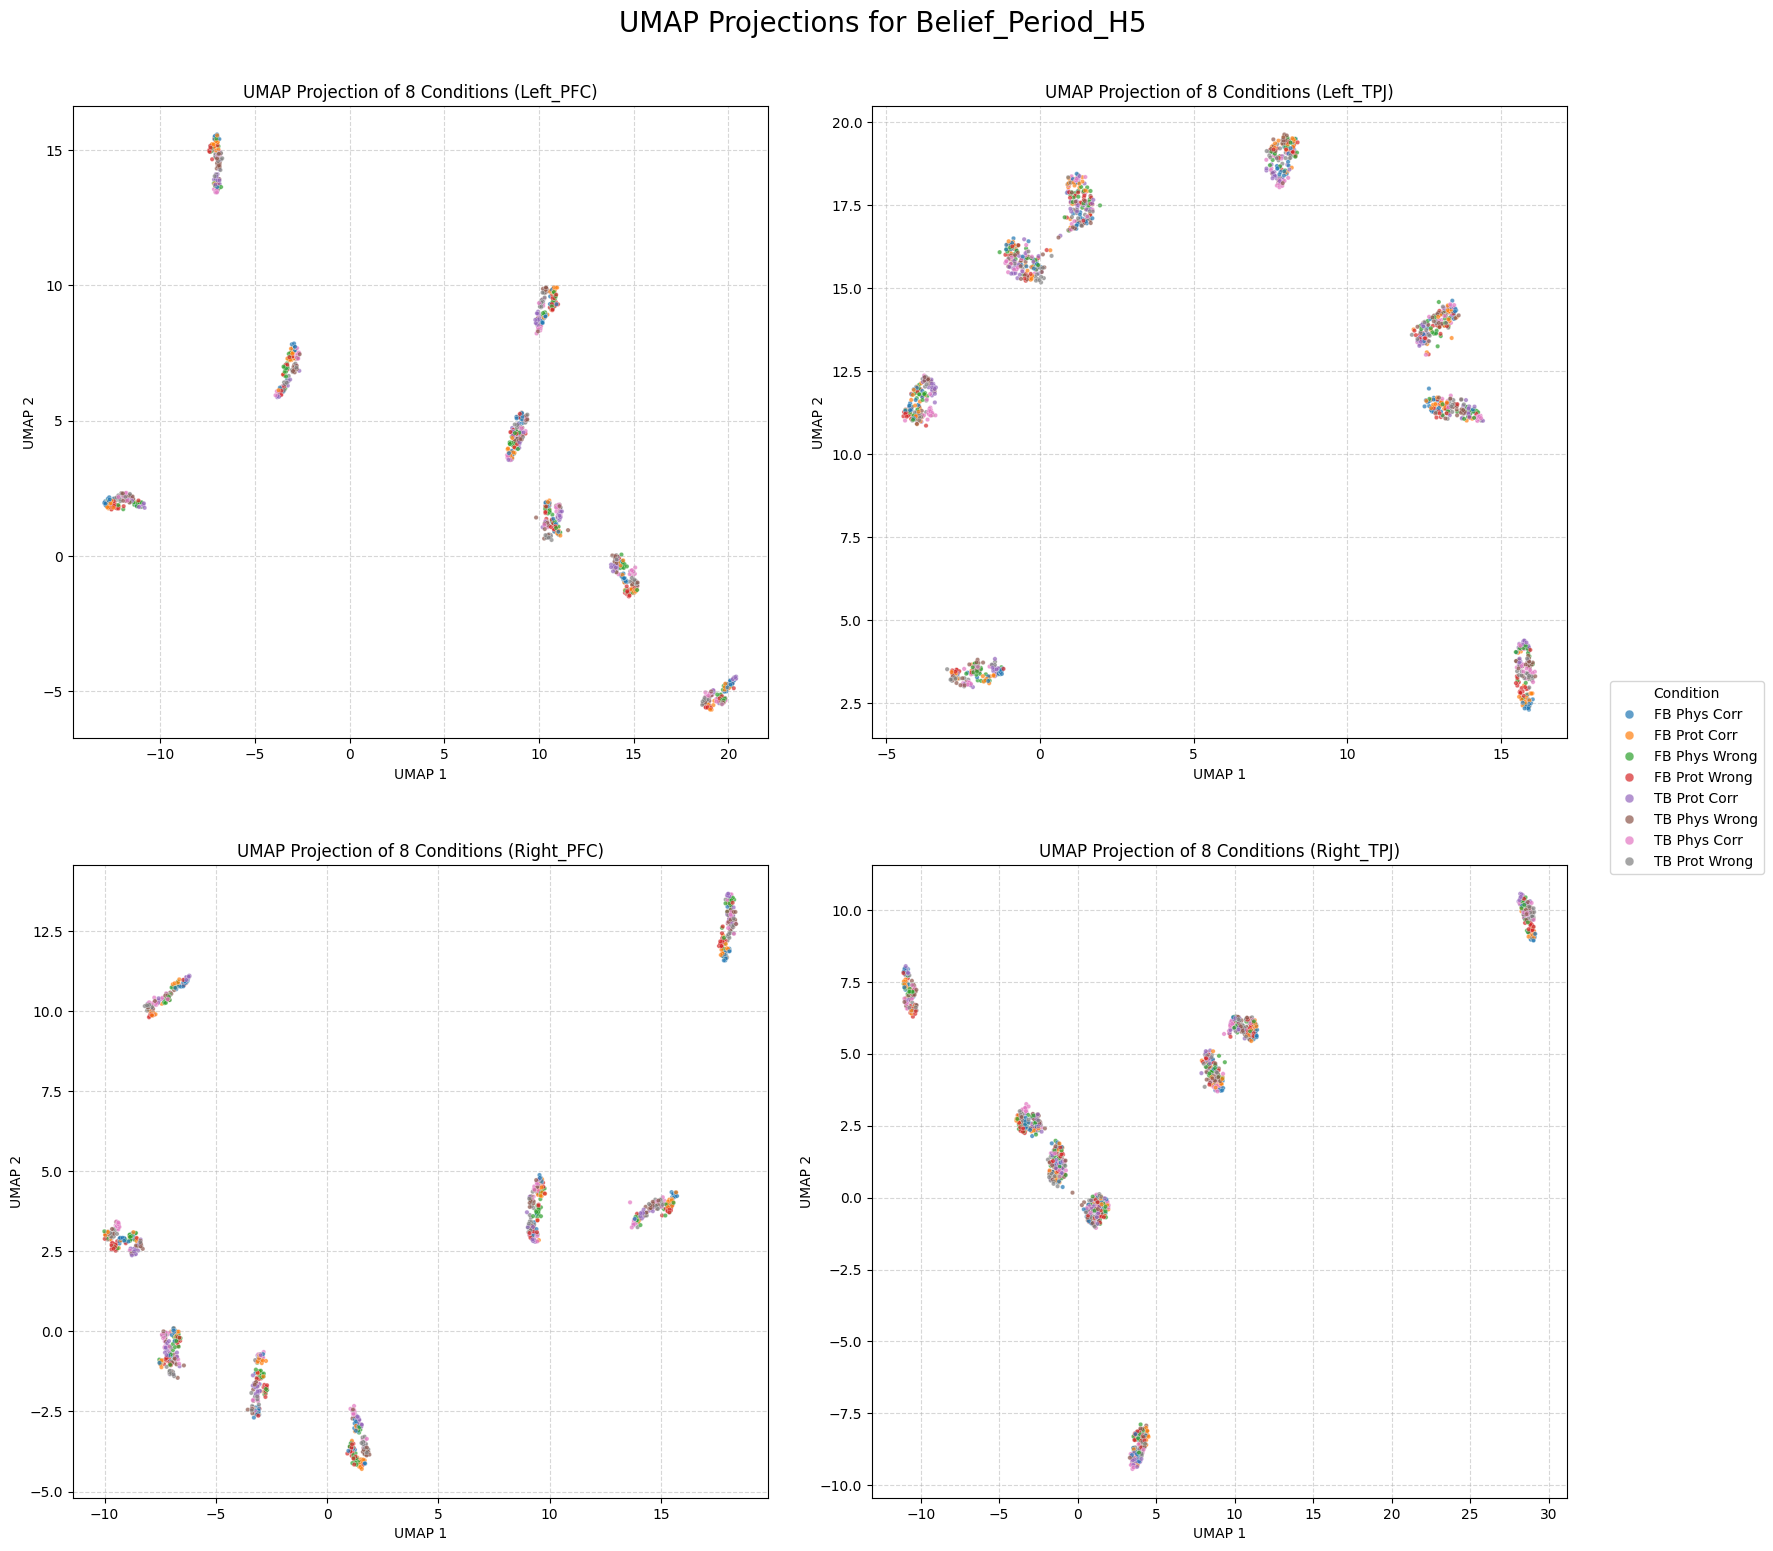


--- 开始处理时期: Perspective_Period_H5 ---
Aggregating data from: Perspective_Period_H5


Aggregating Perspective_Period_H5: 100%|██████████| 20/20 [00:00<00:00, 21.34it/s]


Running UMAP and plotting for Perspective_Period_H5...


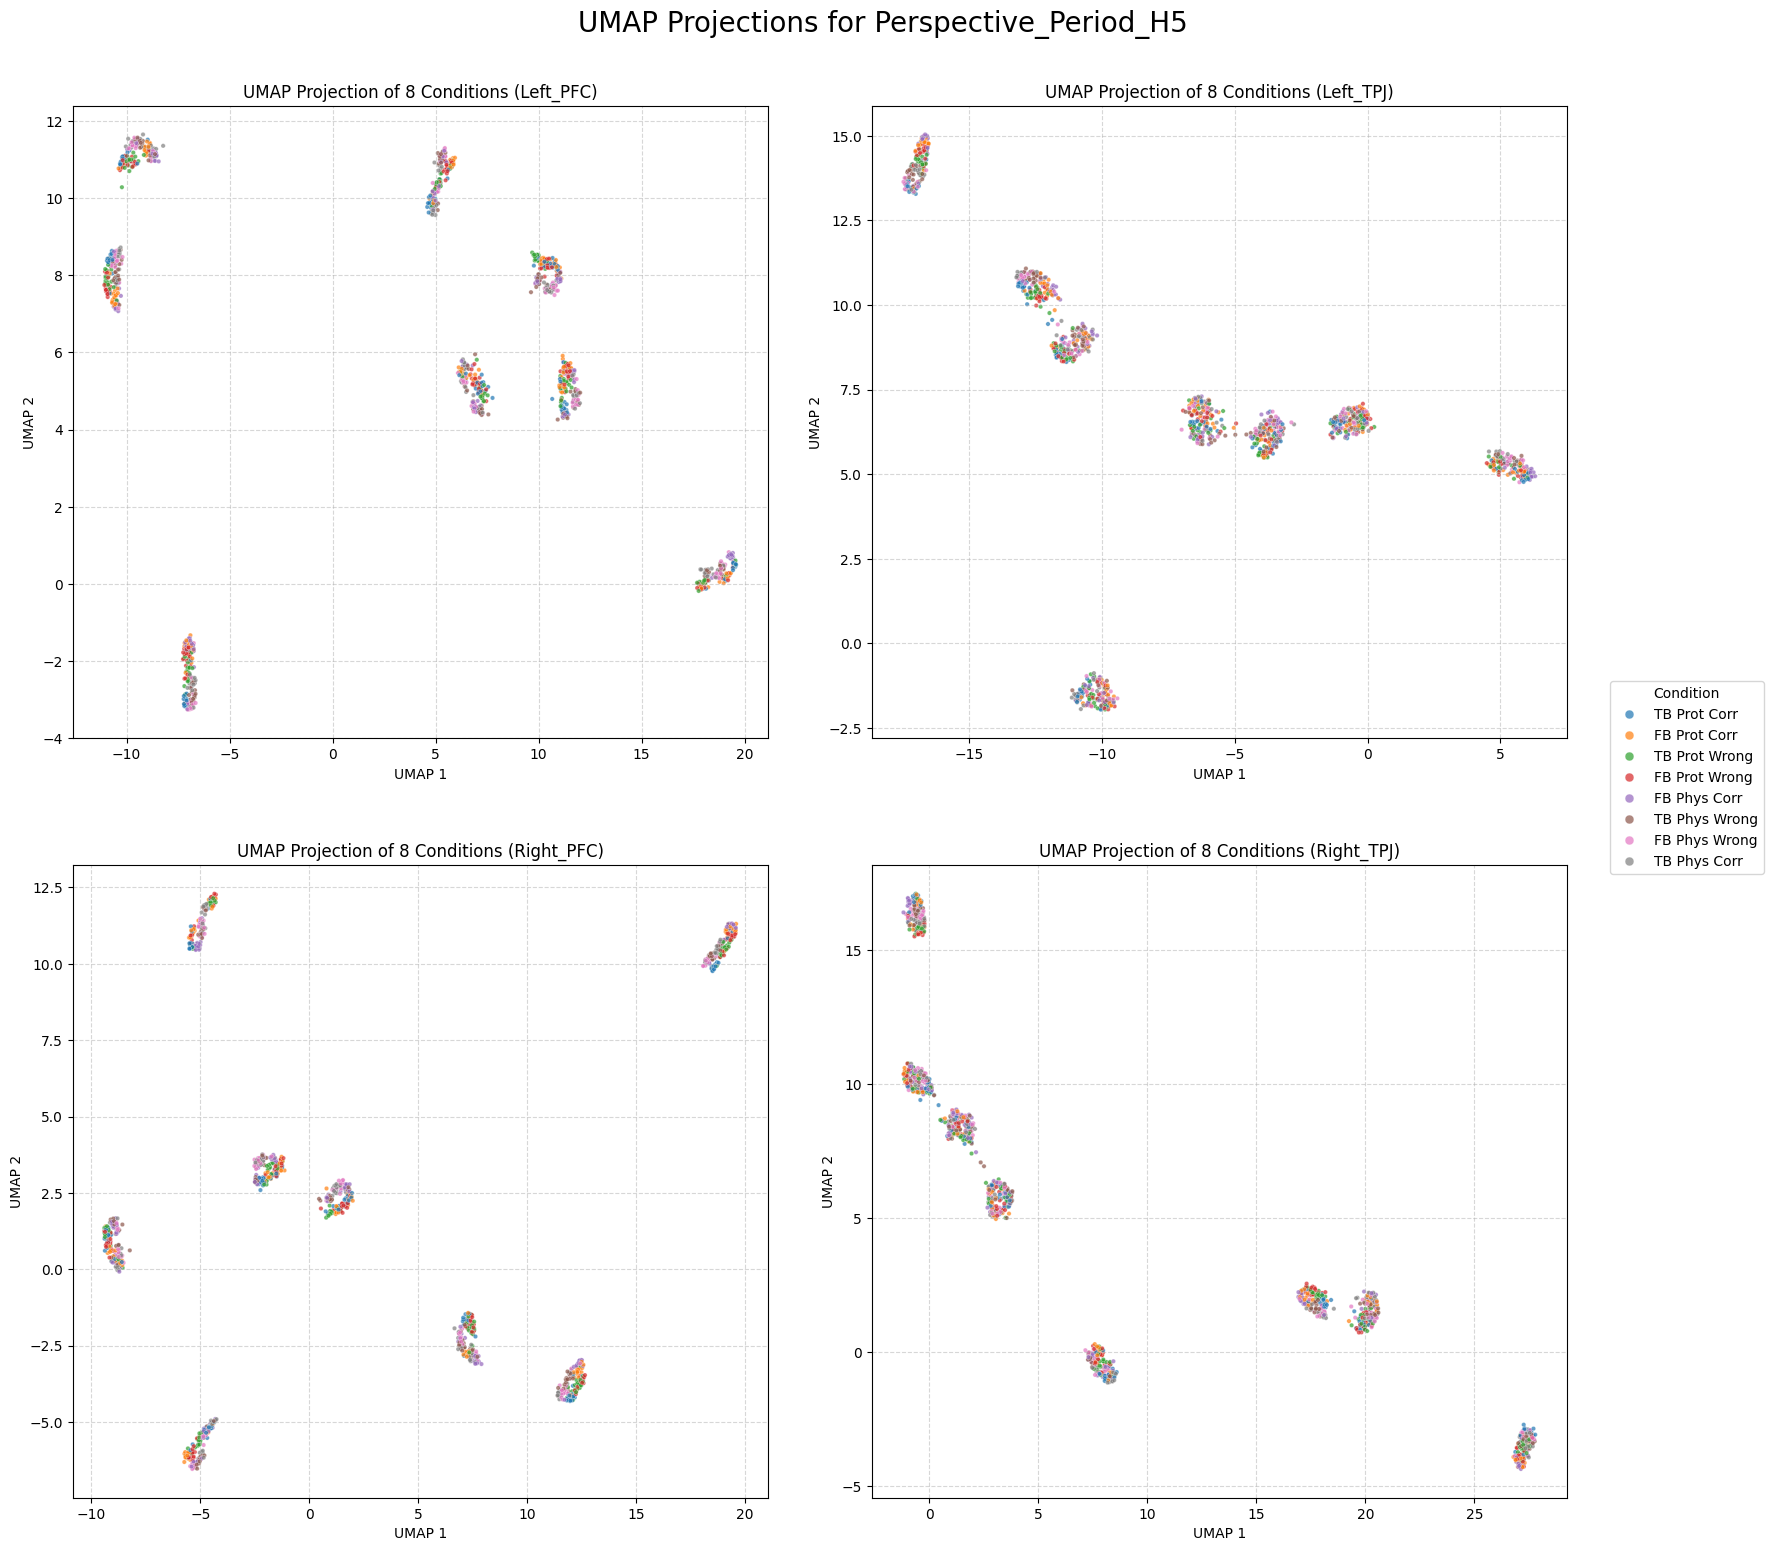

In [28]:
import umap.umap_ as umap
import pandas as pd
from collections import defaultdict

# --- 1. 定义 UMAP 可视化参数 ---

# 8个条件的标签，用于图例 (来自项目描述)
CONDITION_LABELS = [
    "FB Prot Wrong",  # 0
    "FB Prot Corr",  # 1
    "FB Phys Wrong",  # 2
    "FB Phys Corr",  # 3
    "TB Prot Wrong",  # 4
    "TB Prot Corr",  # 5
    "TB Phys Wrong",  # 6
    "TB Phys Corr"  # 7
]

# UMAP 超参数
umap_reducer = umap.UMAP(
    n_neighbors=30,  # 可调：值越大，越关注全局结构
    min_dist=0.1,  # 可调：值越小，聚类越紧密
    n_components=2,
    random_state=42)

for period_to_plot in PERIODS:

    print(f"\n" + "=" * 50)
    print(f"--- 开始处理时期: {period_to_plot} ---")
    print("=" * 50)

    # --- 2. 数据聚合 (Temporal Averaging) ---

    # 字典来存储每个ROI的聚合数据和标签
    # (必须在每个时期的循环开始时重置)
    roi_data = defaultdict(lambda: {'vectors': [], 'labels': []})

    print(f"Aggregating data from: {period_to_plot}")

    # 遍历所有被试
    for sub in tqdm(SUBJECTS, desc=f"Aggregating {period_to_plot}"):
        # 遍历4个脑区
        for roi_file in ROIS:
            roi_name = roi_file.replace(".h5", "")

            # (修改) 使用循环变量 period_to_plot
            pca_file_path = OUTPUT_DIR / period_to_plot / sub / roi_file

            with h5py.File(pca_file_path, 'r') as f:
                for cond_group in f.values():
                    for trial_group in cond_group.values():
                        # 2a. 加载 PCA 信号 (n_time, latent_dim)
                        signal = trial_group['Signal'][()]

                        # 2b. 加载条件标签
                        label = trial_group['Condition_Number'][()]

                        # 2c. 在时间维度上平均
                        proto_vector = np.mean(signal, axis=0)

                        # 2d. 存储原型向量和标签
                        roi_data[roi_name]['vectors'].append(proto_vector)
                        roi_data[roi_name]['labels'].append(label)

    # --- 3. UMAP 拟合与绘图 ---

    print(f"Running UMAP and plotting for {period_to_plot}...")

    # (保持 figsize)
    fig, axes = plt.subplots(2, 2, figsize=(18, 16))
    axes = axes.flatten()  # 将 2x2 矩阵转为 1D 数组
    roi_names_list = [roi.replace(".h5", "") for roi in ROIS]

    # 遍历4个脑区
    for i, (roi_name, ax) in enumerate(zip(roi_names_list, axes)):

        # 3a. 准备数据矩阵
        X = np.array(roi_data[roi_name]['vectors'])
        y = np.array(roi_data[roi_name]['labels'])

        # 3b. 运行 UMAP
        embedding = umap_reducer.fit_transform(X)

        # 3c. 转换为 DataFrame 以便 Seaborn 绘图
        df = pd.DataFrame(embedding, columns=['UMAP 1', 'UMAP 2'])

        # 将数字标签 (0-7) 映射为可读的字符串标签
        df['Condition'] = pd.Series(y).map(lambda x: CONDITION_LABELS[x])

        # 仅在最后一个子图上(临时)创建图例，以便获取handles
        legend_val = None
        if i == len(roi_names_list) - 1:
            legend_val = 'brief'

        # 3d. 绘制散点图
        sns.scatterplot(
            data=df,
            x='UMAP 1',
            y='UMAP 2',
            hue='Condition',
            palette='tab10',  # 使用10色循环调色板
            alpha=0.7,
            s=10,  # 点的大小
            ax=ax,
            legend=legend_val)

        ax.set_title(f'UMAP Projection of 8 Conditions ({roi_name})')
        ax.grid(True, linestyle='--', alpha=0.5)

    # --- 4. 创建一个统一的图例 ---
    handles, labels = ax.get_legend_handles_labels()  # 从最后一个轴获取
    ax.get_legend().remove()  # 移除最后一个轴上的临时图例

    fig.legend(
        handles,
        labels,
        title='Condition',
        loc='center left',  # 图例的锚点
        bbox_to_anchor=(0.9, 0.5),  # 将图例放置在画布宽度90%的位置
        markerscale=2)

    # 移除 y 参数，使其自动定位
    fig.suptitle(f"UMAP Projections for {period_to_plot}", fontsize=20)

    fig.subplots_adjust(
        left=0.05,  # 减小左侧空白
        right=0.88,  # 为图例留出空间 (1.0 - 0.88 = 12%)
        bottom=0.05,  # 减小底部空白
        top=0.92,  # 为总标题留出空间 (1.0 - 0.92 = 8%)
        wspace=0.15,  # 减小横向间距
        hspace=0.2  # 减小纵向间距
    )

    plt.show()

### UMAP within subjects

In [31]:
# --- 定义要绘制的单个被试 ---
SUB_TO_PLOT = 'TOM001'

# --- 遍历两个时期 ---
for period_to_plot in PERIODS:

    print(f"\n" + "=" * 50)
    print(f"--- 开始处理: {SUB_TO_PLOT} | {period_to_plot} ---")
    print("=" * 50)

    # --- 2. 数据聚合 (单个被试) ---

    # 字典来存储每个ROI的聚合数据和标签
    roi_data = defaultdict(lambda: {'vectors': [], 'labels': []})

    print(f"Aggregating data for {SUB_TO_PLOT} from: {period_to_plot}")

    # 遍历4个脑区
    for roi_file in ROIS:
        roi_name = roi_file.replace(".h5", "")

        # 路径指向单个被试
        pca_file_path = OUTPUT_DIR / period_to_plot / SUB_TO_PLOT / roi_file

        with h5py.File(pca_file_path, 'r') as f:
            for cond_group in f.values():
                for trial_group in cond_group.values():
                    # 2a. 加载 PCA 信号 (n_time, latent_dim)
                    signal = trial_group['Signal'][()]

                    # 2b. 加载条件标签
                    label = trial_group['Condition_Number'][()]

                    # 2c. 在时间维度上平均
                    proto_vector = np.mean(signal, axis=0)

                    # 2d. 存储原型向量和标签
                    roi_data[roi_name]['vectors'].append(proto_vector)
                    roi_data[roi_name]['labels'].append(label)

    # --- 3. UMAP 拟合与绘图 ---
    print(f"Running UMAP and plotting for {SUB_TO_PLOT}...")

    # 创建一个 2x2 的子图
    fig, axes = plt.subplots(2, 2, figsize=(18, 16))
    axes = axes.flatten()  # 将 2x2 矩阵转为 1D 数组
    roi_names_list = [roi.replace(".h5", "") for roi in ROIS]

    # 遍历4个脑区
    for i, (roi_name, ax) in enumerate(zip(roi_names_list, axes)):

        # 3a. 准备数据矩阵
        X = np.array(roi_data[roi_name]['vectors'])
        y = np.array(roi_data[roi_name]['labels'])

        # 3b. 运行 UMAP
        embedding = umap_reducer.fit_transform(X)

        # 3c. 转换为 DataFrame 以便 Seaborn 绘图
        df = pd.DataFrame(embedding, columns=['UMAP 1', 'UMAP 2'])

        # 将数字标签 (0-7) 映射为可读的字符串标签
        df['Condition'] = pd.Series(y).map(lambda x: CONDITION_LABELS[x])

        legend_val = None
        if i == len(roi_names_list) - 1:
            legend_val = 'brief'

        # 3d. 绘制散点图
        sns.scatterplot(
            data=df,
            x='UMAP 1',
            y='UMAP 2',
            hue='Condition',
            palette='tab10',
            alpha=0.9,  # (提高 alpha，因为点更少)
            s=25,  # (增大 s，因为点更少)
            ax=ax,
            legend=legend_val)

        ax.set_title(f'UMAP Projection of 8 Conditions ({roi_name})')
        ax.grid(True, linestyle='--', alpha=0.5)

    # --- 4. 创建一个统一的图例 ---
    handles, labels = ax.get_legend_handles_labels()
    ax.get_legend().remove()

    fig.legend(handles, labels, title='Condition', loc='center left', bbox_to_anchor=(0.9, 0.5), markerscale=2)

    # 总标题反映单个被试
    fig.suptitle(f"UMAP Projections for {SUB_TO_PLOT} | {period_to_plot}", fontsize=20)

    # (使用优化后的布局)
    fig.subplots_adjust(left=0.05, right=0.88, bottom=0.05, top=0.92, wspace=0.15, hspace=0.2)

    plt.show()


--- 开始处理: TOM001 | Belief_Period_H5 ---
Aggregating data for TOM001 from: Belief_Period_H5


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'ToM_Data_SRM_LDA_Results/Belief_Period_H5/TOM001/Left_TPJ.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)